In [1]:
import matplotlib.pyplot as plt 
import tensorflow as tf 
import richdem as rd
import numpy as np 

import warnings
warnings.filterwarnings("ignore")


def reconstruct_map(patches, output_shape=(384, 416), patch_size=(32, 32)):
    """Efficiently reconstruct full map from patches.
    Input:
        - patches: tensor: (n,32,32)
    
    """
    grid_height = output_shape[0] // patch_size[0]
    grid_width = output_shape[1] // patch_size[1]
    return patches.reshape(grid_height, grid_width, *patch_size).transpose(0, 2, 1, 3).reshape(output_shape)

def split_patches_2d(tensor, patch_size=(32, 32)):
    # tensor: (384, 416) -> returns (num_patches, 32, 32)
    H, W = tensor.shape
    ph, pw = patch_size
    if H % ph or W % pw:
        raise ValueError("Las dimensiones deben ser múltiplos del patch_size")
    ny, nx = H // ph, W // pw
    patches = np.empty((ny * nx, ph, pw), dtype=tensor.dtype)
    k = 0
    for y in range(0, H, ph):
        for x in range(0, W, pw):
            patches[k] = tensor[y:y+ph, x:x+pw]
            k += 1
    return patches

### Cálculo de variables adicionales: 
#### 1-. Slope y Aspect 

- *Slope* (pendiente): mide qué tan inclinada está la superficie del terreno en cada celda respecto al plano horizontal. Es el ángulo máximo de cambio de elevación. Unidades comunes: grados (0 grados -> plano, 90 grados -> vertical)
- *Aspect* (exposición, aspecto): dirección cardinal hacia la cual “mira” la pendiente máxima de una celda (la orientación de la ladera). Grados acimutales: 0° = Norte, 90° = Este, 180° = Sur, 270° = Oeste. A veces 0–360° o -180–180° según la herramienta.

Nota: Aspect es circular; para modelos es usual convertir a sin(aspect) y cos(aspect)

Importemos HGT y calculemos slope y aspect sobre el mapa completo: (384,416) para evitar potencial inconsistencia en los bordes de los parches: 

Dimensiones HGT parches:  (17784, 32, 32, 1)
Dimensiones HGT mapa:  (384, 416)


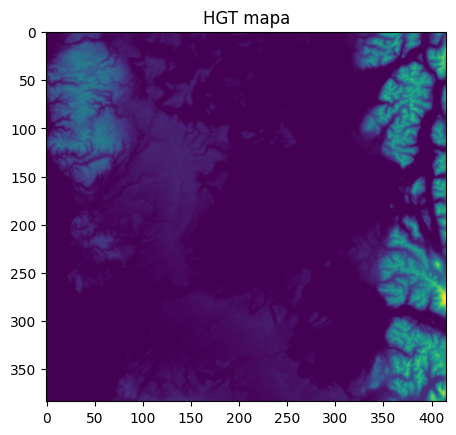

In [3]:
hgt_target_parches = np.load("parches/TR/RAW/hgt_target_raw_parches_TR.npy")
hgt_target_mapa = reconstruct_map(hgt_target_parches[:156,:,:,0] )
print("Dimensiones HGT parches: ", hgt_target_parches.shape)
print("Dimensiones HGT mapa: ", hgt_target_mapa.shape)

plt.title("HGT mapa")
plt.imshow(hgt_target_mapa)

Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)
Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)
Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)
Warning! No geotransform defined. Choosing a standard one! (Top left cell's top let corner at <0,0>; cells are 1x1.)



A Slope calculation (radians)
C Horn, B.K.P., 1981. Hill shading and the reflectance map. Proceedings of the IEEE 69, 14–47. doi:10.1109/PROC.1981.11918

t Wall-time = 0.00483608===================== ] (99% - 0.0s - 1 threads)

A Aspect attribute calculation
C Horn, B.K.P., 1981. Hill shading and the reflectance map. Proceedings of the IEEE 69, 14–47. doi:10.1109/PROC.1981.11918

t Wall-time = 0.00845625===================== ] (99% - 0.0s - 1 threads)


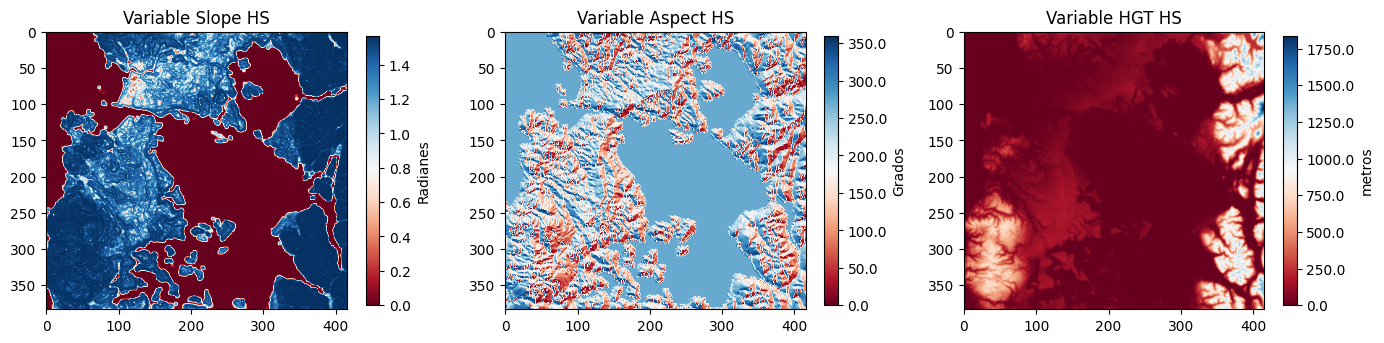

In [4]:
#cálculo slope y aspect - (384,416)
slope_mapa  = rd.TerrainAttribute( rd.rdarray(hgt_target_mapa, no_data=np.nan), attrib='slope_radians')
aspect_mapa = rd.TerrainAttribute( rd.rdarray(hgt_target_mapa, no_data=np.nan), attrib='aspect')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 8))

im1 = ax1.imshow(slope_mapa[::-1],  cmap='RdBu')
ax1.set_title('Variable Slope HS')
cbar1 = fig.colorbar(im1, ax=ax1,label='Radianes', format='%.1f', shrink=0.35)

im2 = ax2.imshow(aspect_mapa[::-1],  cmap='RdBu')
ax2.set_title('Variable Aspect HS')
cbar2 = fig.colorbar(im2, ax=ax2,label='Grados',format='%.1f',shrink=0.35)

im3 = ax3.imshow(hgt_target_mapa[::-1], cmap='RdBu')
ax3.set_title('Variable HGT HS')
cbar3 = fig.colorbar(im3, ax=ax3,label='metros',format='%.1f',shrink=0.35)

plt.tight_layout()
plt.show()

Perfecto. Ahora nos interesa transformar las variables calculadas a parches, copiar sus valores la misma cantidad de veces que HGT versión parches y agregar la dimensión de concatenación: 

In [5]:
slope_156parches  = split_patches_2d(slope_mapa)
aspect_156parches = split_patches_2d(aspect_mapa)

slope_target  = np.expand_dims( np.tile(slope_156parches,  (hgt_target_parches.shape[0] // 156, 1, 1)),  axis=-1)
aspect_target = np.expand_dims( np.tile(aspect_156parches,  (hgt_target_parches.shape[0] // 156, 1, 1)),  axis=-1)

print("Dimensiones slope 156parches: ", slope_156parches.shape)
print("Dimensiones aspect 156parches: ", aspect_156parches.shape)
print("Dimensiones slope parches: ", slope_target.shape)
print("Dimensiones aspect parches: ", aspect_target.shape)

Dimensiones slope 156parches:  (156, 32, 32)
Dimensiones aspect 156parches:  (156, 32, 32)
Dimensiones slope parches:  (17784, 32, 32, 1)
Dimensiones aspect parches:  (17784, 32, 32, 1)


A modo adicional, guardaremos cos(aspect) y sin(aspect): 

In [6]:
rad = np.deg2rad(aspect_target)
aspect_cos_target = np.cos(rad)
aspect_sin_target = np.sin(rad)

print(f"cos(aspect): min={aspect_cos_target.min():.6f}, max={aspect_cos_target.max():.6f}")
print(f"sin(aspect): min={aspect_sin_target.min():.6f}, max={aspect_sin_target.max():.6f}")

cos(aspect): min=-1.000000, max=1.000000
sin(aspect): min=-1.000000, max=1.000000


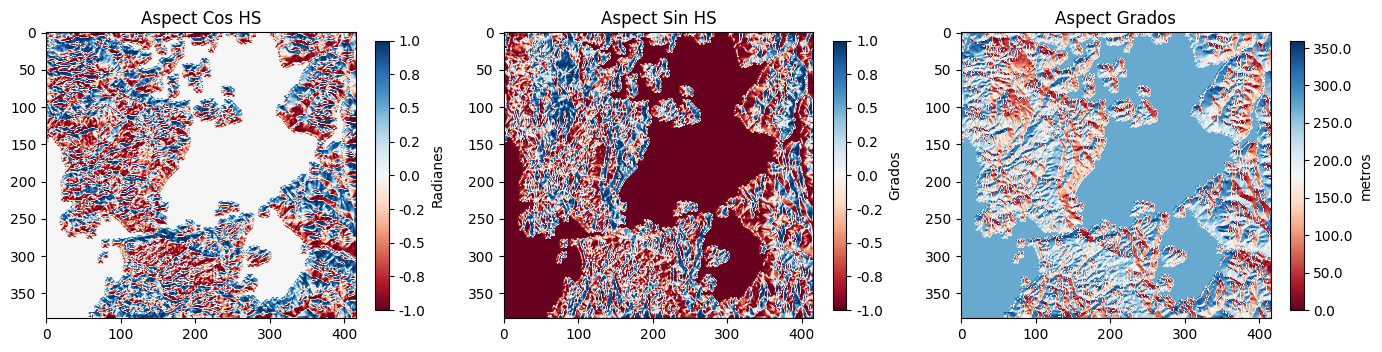

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 8))

im1 = ax1.imshow(reconstruct_map(aspect_cos_target[:156]),  cmap='RdBu')
ax1.set_title('Aspect Cos HS')
cbar1 = fig.colorbar(im1, ax=ax1,label='Radianes', format='%.1f', shrink=0.35)

im2 = ax2.imshow(reconstruct_map(aspect_sin_target[:156]),  cmap='RdBu')
ax2.set_title('Aspect Sin HS')
cbar2 = fig.colorbar(im2, ax=ax2,label='Grados',format='%.1f',shrink=0.35)

im3 = ax3.imshow(aspect_mapa, cmap='RdBu')
ax3.set_title('Aspect Grados')
cbar3 = fig.colorbar(im3, ax=ax3,label='metros',format='%.1f',shrink=0.35)

plt.tight_layout()
plt.show()

In [8]:
np.save("parches/TR/RAW/slope_target_raw_parches_TR.npy", slope_target)
np.save("parches/TR/RAW/aspect_target_raw_parches_TR.npy", aspect_target)
np.save("parches/TR/RAW/aspect_cos_target_raw_parches_TR.npy", aspect_cos_target)
np.save("parches/TR/RAW/aspect_sin_target_raw_parches_TR.npy", aspect_sin_target)

#### 2-. Sheltering y Exposure

- Exposure (exposición): mide qué tan expuesto está un punto del terreno al flujo de viento incidente, considerando la orientación de la ladera y los obstáculos upwind. Alta exposición implica que la topografía no bloquea significativamente el viento desde una dirección dada, por lo que las velocidades locales tienden a ser mayores. Suele estimarse con índices direccionales basados en la pendiente y el aspecto respecto a la dirección del viento (por ejemplo, proyección del vector viento sobre la normal de la ladera o métricas tipo topographic exposure index).
- Sheltering (apantallamiento/abrigo): cuantifica el grado de protección que ofrece la topografía contra el viento desde una dirección específica. Alto sheltering implica que colinas, crestas o relieve upwind bloquean o reducen el flujo, generando velocidades más bajas y zonas de sombra de viento. Se calcula con índices que integran obstáculos a lo largo de una línea de visión en la dirección del viento (p. ej., sky-view obstruction, indices de bloqueo direccional, o “wind sheltering index” que evalúa pendientes y elevaciones upwind en distancias definidas). 

La fórmula es la siguiente: 

\begin{equation}
\begin{cases}
 E_{+} = \max (\sin (\alpha ),0 ), \\
 E_{-} = \min (\sin (\alpha ),0 )
\end{cases}
\end{equation}
donde

\begin{equation*}
\alpha = \arctan ( \tan (slope) \cos (\delta)), \text{ con } \\ 
\delta = \arctan2 (-v_{c}, -u_{c}) - aspect
\end{equation*}

Acá tenemos que tener en cuenta lo siguiente: 
- $u_{c}, v_{c}$ corresponde a la velocidad en el centro del parche 
- Nuestro aspect se encuentra en grados
- Es una fórmula calculada punto a punto, por lo cual es indistinto si se trabaja con la forma de parches o forma de mapa (previa consideración de $u_{c}, v_{c}$ ).

Importemos las variables necesarias. 

##### 2.1 $E_{+}$ y $E_{-}$ para el entrenamiento: 


In [10]:
import matplotlib.pyplot as plt 
import numpy as np

u10_input_tr = np.load("parches/TR/RAW/u10_input_raw_parches_TR.npy")
v10_input_tr = np.load("parches/TR/RAW/v10_input_raw_parches_TR.npy")
speed_input_tr = np.load("parches/TR/RAW/speed_input_raw_parches_TR.npy")
slope_tr  = np.load("parches/TR/RAW/slope_target_raw_parches_TR.npy")
aspect_tr = np.load("parches/TR/RAW/aspect_target_raw_parches_TR.npy")
print("u10 shape: ", u10_input_tr.shape)
print("v10 shape: ", v10_input_tr.shape)
print(f"slope shape: , {slope_tr.shape}, min={slope_tr.min():.6f}, max={slope_tr.max():.6f}") #radianes
print(f"aspect shape: , {aspect_tr.shape}, min={aspect_tr.min():.6f}, max={aspect_tr.max():.6f}") #grados

u10 shape:  (17784, 32, 32, 1)
v10 shape:  (17784, 32, 32, 1)
slope shape: , (17784, 32, 32, 1), min=0.000000, max=1.568081
aspect shape: , (17784, 32, 32, 1), min=0.000000, max=359.996246


In [11]:
def compute_exposure_sheltering_with_center_wind(u10_input, v10_input, slope_rad, aspect_deg):
    # u10_input, v10_input, slope_rad: (N, 32, 32, 1)
    # aspect_deg: (N, 32, 32, 1) en grados
    # slope ya en radianes; aspect lo convertimos a radianes
    aspect = np.deg2rad(aspect_deg)

    # u_c y v_c: viento del centro del parche (constante dentro de cada 32x32)
    u_c = u10_input[:, 16:17, 16:17, :]  # (N,1,1,1)
    v_c = v10_input[:, 16:17, 16:17, :]  # (N,1,1,1)

    # Alternativa (promedio espacial del parche):
    # u_c = u10_input.mean(axis=(1,2), keepdims=True)  # (N,1,1,1)
    # v_c = v10_input.mean(axis=(1,2), keepdims=True)  # (N,1,1,1)

    # Expandir u_c, v_c a 32x32 por broadcasting
    u_c = np.broadcast_to(u_c, u10_input.shape)
    v_c = np.broadcast_to(v_c, v10_input.shape)

    # delta = atan2(-v_c, -u_c) - aspect
    delta = np.arctan2(-v_c, -u_c) - aspect

    # a = arctan( tan(slope) * cos(delta) )
    a = np.arctan(np.tan(slope_rad) * np.cos(delta))

    # E_plus = max(sin(a), 0), E_min = min(sin(a), 0)
    sin_a = np.sin(a)
    E_plus = np.maximum(sin_a, 0.0)
    E_min  = np.minimum(sin_a, 0.0)

    return E_plus, E_min

In [12]:
E_plus_tr, E_min_tr = compute_exposure_sheltering_with_center_wind(u10_input_tr, v10_input_tr, slope_tr, aspect_tr)
print(f"Exposure shape: , {E_plus_tr.shape}, min={E_plus_tr.min():.6f}, max={E_plus_tr.max():.6f}") #radianes
print(f"Sheltering shape: , {E_min_tr.shape}, min={E_min_tr.min():.6f}, max={E_min_tr.max():.6f}") #grados

Exposure shape: , (17784, 32, 32, 1), min=0.000000, max=0.999996
Sheltering shape: , (17784, 32, 32, 1), min=-0.999996, max=0.000000


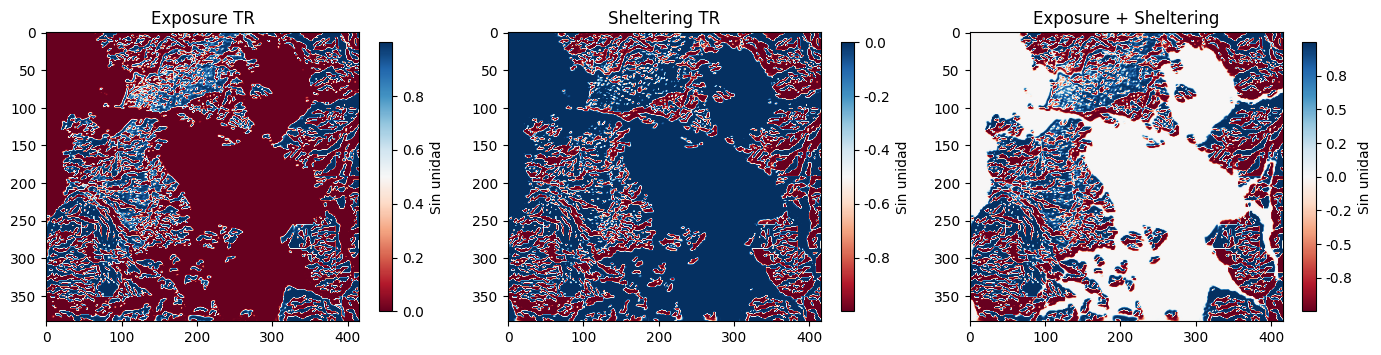

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 8))

E_plus_i = reconstruct_map(E_plus_tr[:156])
E_min_i  = reconstruct_map(E_min_tr[:156])

im1 = ax1.imshow(E_plus_i[::-1],  cmap='RdBu')
ax1.set_title('Exposure TR')
cbar1 = fig.colorbar(im1, ax=ax1,label='Sin unidad', format='%.1f', shrink=0.35)

im2 = ax2.imshow(E_min_i[::-1],  cmap='RdBu')
ax2.set_title('Sheltering TR')
cbar2 = fig.colorbar(im2, ax=ax2,label='Sin unidad',format='%.1f',shrink=0.35)

im3 = ax3.imshow(E_plus_i[::-1] + E_min_i[::-1], cmap='RdBu')
ax3.set_title('Exposure + Sheltering')
cbar3 = fig.colorbar(im3, ax=ax3,label='Sin unidad',format='%.1f',shrink=0.35)

plt.tight_layout()
plt.show()

Y guardamos nuestras variables correspondientes. Cabe mencionar que en el artículo de Dupuy no solo se utilizan estas variables $E_{plus} - E_{min}$ en su forma base sino que también su producto cruz con las componentes del viento y con la velocidad: 

In [14]:
np.save("parches/TR/RAW/Eplus_input_raw_parches_TR.npy", E_plus_tr)
np.save("parches/TR/RAW/Emin_input_raw_parches_TR.npy",  E_min_tr)

np.save("parches/TR/RAW/EplusU_input_raw_parches_TR.npy", E_plus_tr * u10_input_tr)
np.save("parches/TR/RAW/EplusV_input_raw_parches_TR.npy", E_plus_tr * v10_input_tr)
np.save("parches/TR/RAW/EminU_input_raw_parches_TR.npy",  E_min_tr * u10_input_tr)
np.save("parches/TR/RAW/EminV_input_raw_parches_TR.npy",  E_min_tr * v10_input_tr)

np.save("parches/TR/RAW/EplusUV_input_raw_parches_TR.npy", E_plus_tr * speed_input_tr)
np.save("parches/TR/RAW/EminUV_input_raw_parches_TR.npy",  E_min_tr  * speed_input_tr)

##### 2.2 $E_{+}$ y $E_{-}$ para validación: 

In [20]:
u10_input_va =   np.load("parches/VA/RAW/u10_input_raw_parches_VA.npy")
v10_input_va =   np.load("parches/VA/RAW/v10_input_raw_parches_VA.npy")
speed_input_va = np.load("parches/VA/RAW/speed_input_raw_parches_VA.npy")
slope_va  =      np.load("parches/VA/RAW/slope_target_raw_parches_VA.npy")
aspect_va =      np.load("parches/VA/RAW/aspect_target_raw_parches_VA.npy")
print("u10 shape: ", u10_input_va.shape)
print("v10 shape: ", v10_input_va.shape)
print(f"slope shape: , {slope_va.shape}, min={slope_va.min():.6f}, max={slope_va.max():.6f}") #radianes
print(f"aspect shape: , {aspect_va.shape}, min={aspect_va.min():.6f}, max={aspect_va.max():.6f}") #grados

u10 shape:  (142272, 32, 32, 1)
v10 shape:  (142272, 32, 32, 1)
slope shape: , (142272, 32, 32, 1), min=0.000000, max=1.568081
aspect shape: , (142272, 32, 32, 1), min=0.000000, max=359.996246


In [21]:
E_plus_va, E_min_va = compute_exposure_sheltering_with_center_wind(u10_input_va, v10_input_va, slope_va, aspect_va)
print(f"Exposure shape: , {E_plus_va.shape}, min={E_plus_va.min():.6f}, max={E_plus_va.max():.6f}") #radianes
print(f"Sheltering shape: , {E_min_va.shape}, min={E_min_va.min():.6f}, max={E_min_va.max():.6f}") #grados

Exposure shape: , (142272, 32, 32, 1), min=0.000000, max=0.999996
Sheltering shape: , (142272, 32, 32, 1), min=-0.999996, max=0.000000


In [22]:
np.save("parches/VA/RAW/Eplus_input_raw_parches_VA.npy", E_plus_va)
np.save("parches/VA/RAW/Emin_input_raw_parches_VA.npy",  E_min_va)

np.save("parches/VA/RAW/EplusU_input_raw_parches_VA.npy", E_plus_va * u10_input_va)
np.save("parches/VA/RAW/EplusV_input_raw_parches_VA.npy", E_plus_va * v10_input_va)
np.save("parches/VA/RAW/EminU_input_raw_parches_VA.npy",  E_min_va * u10_input_va)
np.save("parches/VA/RAW/EminV_input_raw_parches_VA.npy",  E_min_va * v10_input_va)

np.save("parches/VA/RAW/EplusUV_input_raw_parches_VA.npy", E_plus_va * speed_input_va)
np.save("parches/VA/RAW/EminUV_input_raw_parches_VA.npy",  E_min_va  * speed_input_va)

##### 2.3 $E_{+}$ y $E_{-}$ para testeo:

In [23]:
u10_input_te =   np.load("parches/TE/RAW/u10_input_raw_parches_TE.npy")
v10_input_te =   np.load("parches/TE/RAW/v10_input_raw_parches_TE.npy")
speed_input_te = np.load("parches/TE/RAW/speed_input_raw_parches_TE.npy")
slope_te  =      np.load("parches/TE/RAW/slope_target_raw_parches_TE.npy")
aspect_te =      np.load("parches/TE/RAW/aspect_target_raw_parches_TE.npy")
print("u10 shape: ", u10_input_te.shape)
print("v10 shape: ", v10_input_te.shape)
print(f"slope shape: , {slope_te.shape}, min={slope_te.min():.6f}, max={slope_te.max():.6f}") #radianes
print(f"aspect shape: , {aspect_te.shape}, min={aspect_te.min():.6f}, max={aspect_te.max():.6f}") #grados

u10 shape:  (142272, 32, 32, 1)
v10 shape:  (142272, 32, 32, 1)
slope shape: , (142272, 32, 32, 1), min=0.000000, max=1.568081
aspect shape: , (142272, 32, 32, 1), min=0.000000, max=359.996246


In [24]:
E_plus_te, E_min_te = compute_exposure_sheltering_with_center_wind(u10_input_te, v10_input_te, slope_te, aspect_te)
print(f"Exposure shape: , {E_plus_te.shape}, min={E_plus_te.min():.6f}, max={E_plus_te.max():.6f}") #radianes
print(f"Sheltering shape: , {E_min_te.shape}, min={E_min_te.min():.6f}, max={E_min_te.max():.6f}") #grados

Exposure shape: , (142272, 32, 32, 1), min=0.000000, max=0.999996
Sheltering shape: , (142272, 32, 32, 1), min=-0.999996, max=0.000000


In [25]:
np.save("parches/TE/RAW/Eplus_input_raw_parches_TE.npy", E_plus_te)
np.save("parches/TE/RAW/Emin_input_raw_parches_TE.npy",  E_min_te)

np.save("parches/TE/RAW/EplusU_input_raw_parches_TE.npy", E_plus_te * u10_input_te)
np.save("parches/TE/RAW/EplusV_input_raw_parches_TE.npy", E_plus_te * v10_input_te)
np.save("parches/TE/RAW/EminU_input_raw_parches_TE.npy",  E_min_te * u10_input_te)
np.save("parches/TE/RAW/EminV_input_raw_parches_TE.npy",  E_min_te * v10_input_te)

np.save("parches/TE/RAW/EplusUV_input_raw_parches_TE.npy", E_plus_te * speed_input_te)
np.save("parches/TE/RAW/EminUV_input_raw_parches_TE.npy",  E_min_te  * speed_input_te)

#### 3-. U tangencial

Los dos descriptores restantes abordan el desafío de la deflexión del viento: cómo cambiar $u_c$ y $v_c$ para obtener un flujo que gire cuando se enfrenta a una pendiente pronunciada. Proporcionamos al modelo los desplazamientos para $u_c$ y $v_c$, $\Delta u_{\text{tan}}$ y $\Delta v_{\text{tan}}$, necesarios para obtener tal efecto. La Ecuación 2 muestra que cuanto más pronunciada sea la pendiente, más tendrá que seguir el flujo los contornos topográficos (ser tangencial). Esto se realiza mediante una rotación del vector $(u_c, v_c)$ por un ángulo $\beta$. Este ángulo se calcula utilizando el ángulo de pendiente y $\delta$, que es el mismo ángulo que en la Ecuación 1. Usando las observaciones como guía, Wind-Topo aprende cuánto, dónde y cuándo deben emplearse estas deflexiones de exposición, protección y teóricas:

\begin{equation}
\begin{cases}
\Delta u_{\text{tan}} = (\cos(\beta)-1)u_c-\sin(\beta)v_c, \\ \Delta v_{\text{tan}} = \sin(\beta)u_c+(\cos(\beta)-1)v_c,
\end{cases}
\end{equation}
donde

\begin{equation}
\beta = (\frac{\pi}{2}-|\delta|)\text{sign}(\delta)\sin(\text{slope}), \text{ con } \tag{2}
\end{equation}
$\delta \in [-\pi,\pi]$ de la Ecuación 1.

Procedamos al cálculo! 

In [15]:
def compute_deflection_deltas(u10_input, v10_input, slope_rad, aspect_deg):
    # aspect a radianes
    aspect = np.deg2rad(aspect_deg)

    # Viento del centro del parche (N,1,1,1)
    u_c = u10_input[:, 16:17, 16:17, :]
    v_c = v10_input[:, 16:17, 16:17, :]

    # Alternativa: promedio espacial del parche
    #u_c = u10_input.mean(axis=(1,2), keepdims=True)
    #v_c = v10_input.mean(axis=(1,2), keepdims=True)

    # Broadcast a (N,32,32,1)
    u_c = np.broadcast_to(u_c, u10_input.shape)
    v_c = np.broadcast_to(v_c, v10_input.shape)

    # δ = atan2(-v_c, -u_c) - aspect
    delta = np.arctan2(-v_c, -u_c) - aspect

    # β = (π/2 - |δ|) * sign(δ) * sin(slope)
    beta = (np.pi / 2 - np.abs(delta)) * np.sign(delta) * np.sin(slope_rad)

    cosb = np.cos(beta)
    sinb = np.sin(beta)

    # Δu_tan y Δv_tan
    delta_u_tan = (cosb - 1.0) * u_c - sinb * v_c
    delta_v_tan =  sinb * u_c + (cosb - 1.0) * v_c

    return delta_u_tan, delta_v_tan

##### 3.1 U_tangencial entrenamiento: 

In [16]:
delta_u_tr, delta_v_tr = compute_deflection_deltas(u10_input_tr, v10_input_tr, slope_tr, aspect_tr)

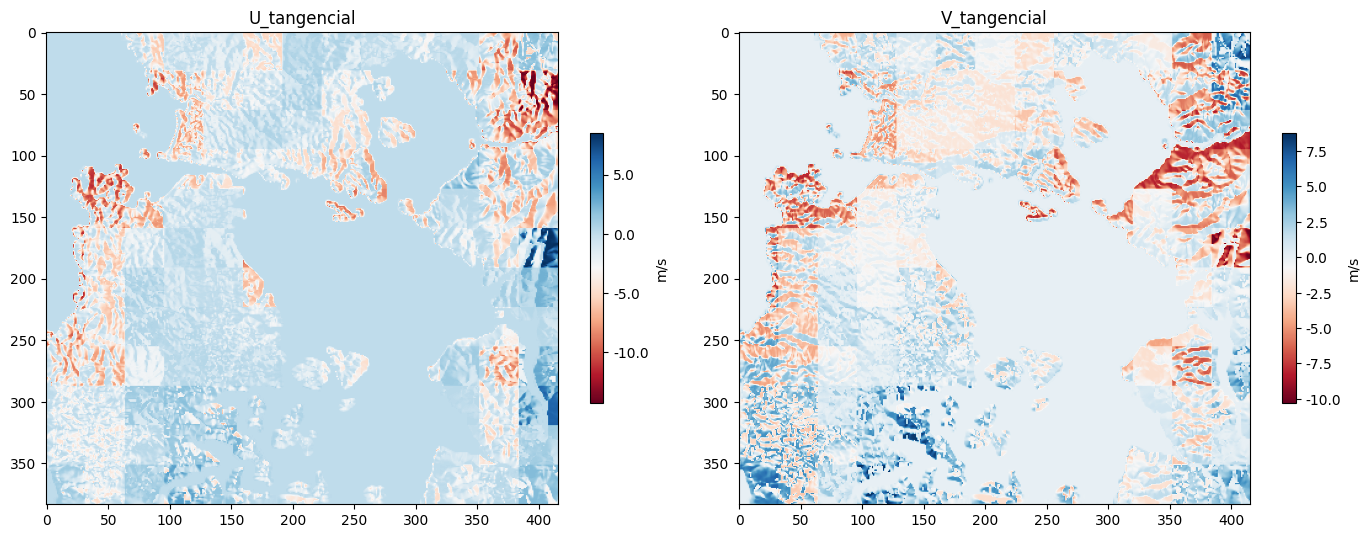

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

i=2
delta_u_i  = reconstruct_map(delta_u_tr[i*156:156*(i+1)])
delta_v_i  = reconstruct_map(delta_v_tr[i*156:156*(i+1)])

im1 = ax1.imshow(delta_u_i[::-1],  cmap='RdBu')
ax1.set_title('U_tangencial')
cbar1 = fig.colorbar(im1, ax=ax1,label='m/s', format='%.1f', shrink=0.35)

im2 = ax2.imshow(delta_v_i[::-1],  cmap='RdBu')
ax2.set_title('V_tangencial')
cbar2 = fig.colorbar(im2, ax=ax2,label='m/s',format='%.1f',shrink=0.35)

plt.tight_layout()
plt.show()

In [18]:
np.save("parches/TR/RAW/Utan_input_raw_parches_TR.npy",  delta_u_tr)
np.save("parches/TR/RAW/Vtan_input_raw_parches_TR.npy",  delta_v_tr)

##### 3.2 U_tangencial validación: 

In [19]:
delta_u_va, delta_v_va = compute_deflection_deltas(u10_input_va, v10_input_va, slope_va, aspect_va)

np.save("parches/VA/RAW/Utan_input_raw_parches_VA.npy",  delta_u_va)
np.save("parches/VA/RAW/Vtan_input_raw_parches_VA.npy",  delta_v_va)

NameError: name 'u10_input_va' is not defined

##### 3.3 U_tangencial testeo: 

In [44]:
delta_u_te, delta_v_te = compute_deflection_deltas(u10_input_te, v10_input_te, slope_te, aspect_te)

np.save("parches/TE/RAW/Utan_input_raw_parches_TE.npy",  delta_u_te)
np.save("parches/TE/RAW/Vtan_input_raw_parches_TE.npy",  delta_v_te)